### Notebook de testes para encontrar o melhor backtest do modelo

In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import bs4 as bs
import seaborn as sns
import requests
import time
import requests
import optuna
import threading

from funcoes import (
    pca_portfolio_spy,
    pca_portfolio_spy_hedge,
    stats_from_returns,
    pca_portfolio_spy_adaptive_pcs,
    pca_portfolio_spy_var
)

from analise_estrategia import analyze_strategy 

d:\savio\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Carregar dados
start_date = "1997-01-02"
end_date = "2007-12-31"

data = pd.read_csv("dados_full_1997_2007.csv", index_col=0)
#data = pd.read_csv("dados_1997_2025.csv", index_col=0)
data.index = pd.to_datetime(data.index)
data = data.sort_index()

returns = data.pct_change()
returns.dropna(inplace=True,axis=0, how='all')
returns.dropna(inplace=True,axis=1, how='any')
returns = returns.loc[start_date:end_date]

# Baixar dados do SPY para o mesmo período
data_spy = yf.download("SPY", start=start_date, end=end_date, auto_adjust=True)["Close"]
data_spy.index = pd.to_datetime(data_spy.index)
data_spy = data_spy.sort_index()
returns_spy = data_spy.pct_change()
returns_spy.dropna(inplace=True)

# Garantir que ambos os DataFrames tenham índices coerentes e ordenados (sem timezone)
returns.index     = pd.to_datetime(returns.index).tz_localize(None)
returns_spy.index = pd.to_datetime(returns_spy.index).tz_localize(None)
returns     = returns.sort_index()
returns_spy = returns_spy.sort_index()

[*********************100%***********************]  1 of 1 completed


In [4]:
# pegar os tickers e atualizar os dados até 2025
tickers = data.columns.tolist()
len(tickers)

417

In [5]:
# verificando dados ruins
bad_tickers = []

for col in data.columns:
    p = data[col]
    if p.min() <= 0:
        bad_tickers.append(col)
        continue
    if (p.max() / p.min()) > 1e3:  # variação absurda de escala
        bad_tickers.append(col)

data = data.drop(columns=bad_tickers, errors="ignore")
returns = returns.drop(columns=bad_tickers, errors="ignore")

bad_tickers

[]

In [6]:
returns.head()

,MMM,AOS,ABT,ADBE,AMD,AES,AFL,APD,ALB,LNT,...,WEC,WFC,WELL,WST,WDC,WY,WSM,WMB,XEL,ZBRA
Date,,,,,,,,,,,,,,,,,,,,,
1997-01-03,-0.017392,-0.008404,0.022333,0.012945,0.032258,-0.002754,0.002915,0.016513,-0.019608,0.004464,...,0.004673,0.020232,0.015544,-0.004465,0.043280,0.000000,0.037838,0.017182,0.002732,0.037634
1997-01-06,0.001476,-0.012712,-0.012136,0.035144,0.017857,0.027624,0.011628,0.005415,0.020000,0.004444,...,0.004651,-0.011332,-0.005103,-0.004484,0.043668,0.013263,-0.059028,0.013513,0.005449,0.015544
1997-01-07,-0.011783,0.030043,0.022112,0.040124,0.048246,0.010752,-0.005747,-0.003590,-0.006536,-0.004424,...,0.000000,0.011462,-0.010256,0.009009,-0.004184,0.013089,0.029521,0.020000,0.005421,0.091837
1997-01-08,-0.001490,-0.004167,-0.014423,0.002967,-0.033473,0.007979,0.005780,0.005405,-0.019736,0.000000,...,0.009259,0.005666,-0.010363,-0.008929,0.039916,0.007751,-0.021506,0.009804,0.010782,-0.018692
1997-01-09,-0.001493,-0.004183,0.009757,-0.020710,-0.047619,0.002638,-0.008621,-0.001792,0.013422,0.004444,...,0.018349,0.000000,0.020942,0.000000,0.020202,-0.002564,0.069597,0.019418,0.002666,0.038095


Tempo : 1999-03-29 00:00:00
Tempo : 1999-03-30 00:00:00
Tempo : 1999-03-31 00:00:00
Tempo : 1999-04-01 00:00:00
Tempo : 1999-04-05 00:00:00
Tempo : 1999-04-06 00:00:00
Tempo : 1999-04-07 00:00:00
Tempo : 1999-04-08 00:00:00
Tempo : 1999-04-09 00:00:00
Tempo : 1999-04-12 00:00:00
Tempo : 1999-04-13 00:00:00
Tempo : 1999-04-14 00:00:00
Tempo : 1999-04-15 00:00:00
Tempo : 1999-04-16 00:00:00
Tempo : 1999-04-19 00:00:00
Tempo : 1999-04-20 00:00:00
Tempo : 1999-04-21 00:00:00
Tempo : 1999-04-22 00:00:00
Tempo : 1999-04-23 00:00:00
Tempo : 1999-04-26 00:00:00
Tempo : 1999-04-27 00:00:00
Tempo : 1999-04-28 00:00:00
Tempo : 1999-04-29 00:00:00
Tempo : 1999-04-30 00:00:00
Tempo : 1999-05-03 00:00:00
Tempo : 1999-05-04 00:00:00
Tempo : 1999-05-05 00:00:00
Tempo : 1999-05-06 00:00:00
Tempo : 1999-05-07 00:00:00
Tempo : 1999-05-10 00:00:00
Tempo : 1999-05-11 00:00:00
Tempo : 1999-05-12 00:00:00
Tempo : 1999-05-13 00:00:00
Tempo : 1999-05-14 00:00:00
Tempo : 1999-05-17 00:00:00
Tempo : 1999-05-18 0

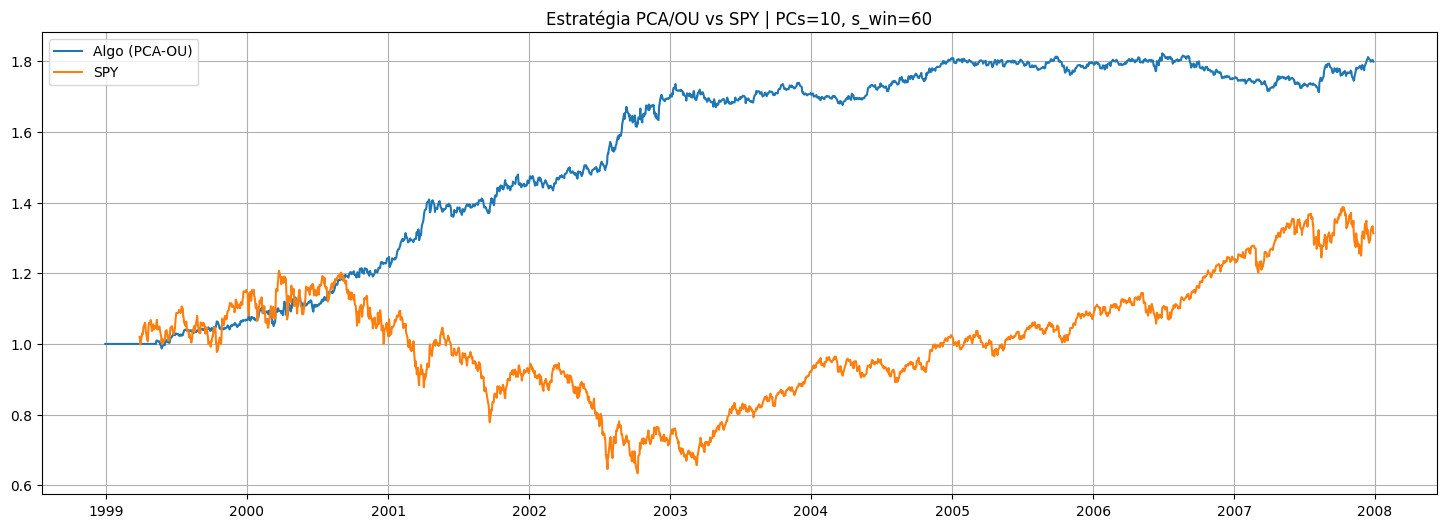

In [ ]:
# Melhor

# Rodar experimento 03 : (n = 10, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 1) (padronizado)
results = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_spy,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True
)

Tempo : 1997-04-01 00:00:00
Tempo : 1997-04-02 00:00:00
Tempo : 1997-04-03 00:00:00
Tempo : 1997-04-04 00:00:00
Tempo : 1997-04-07 00:00:00
Tempo : 1997-04-08 00:00:00
Tempo : 1997-04-09 00:00:00
Tempo : 1997-04-10 00:00:00
Tempo : 1997-04-11 00:00:00
Tempo : 1997-04-14 00:00:00
Tempo : 1997-04-15 00:00:00
Tempo : 1997-04-16 00:00:00
Tempo : 1997-04-17 00:00:00
Tempo : 1997-04-18 00:00:00
Tempo : 1997-04-21 00:00:00
Tempo : 1997-04-22 00:00:00
Tempo : 1997-04-23 00:00:00
Tempo : 1997-04-24 00:00:00
Tempo : 1997-04-25 00:00:00
Tempo : 1997-04-28 00:00:00
Tempo : 1997-04-29 00:00:00
Tempo : 1997-04-30 00:00:00
Tempo : 1997-05-01 00:00:00
Tempo : 1997-05-02 00:00:00
Tempo : 1997-05-05 00:00:00
Tempo : 1997-05-06 00:00:00
Tempo : 1997-05-07 00:00:00
Tempo : 1997-05-08 00:00:00
Tempo : 1997-05-09 00:00:00
Tempo : 1997-05-12 00:00:00
Tempo : 1997-05-13 00:00:00
Tempo : 1997-05-14 00:00:00
Tempo : 1997-05-15 00:00:00
Tempo : 1997-05-16 00:00:00
Tempo : 1997-05-19 00:00:00
Tempo : 1997-05-20 0

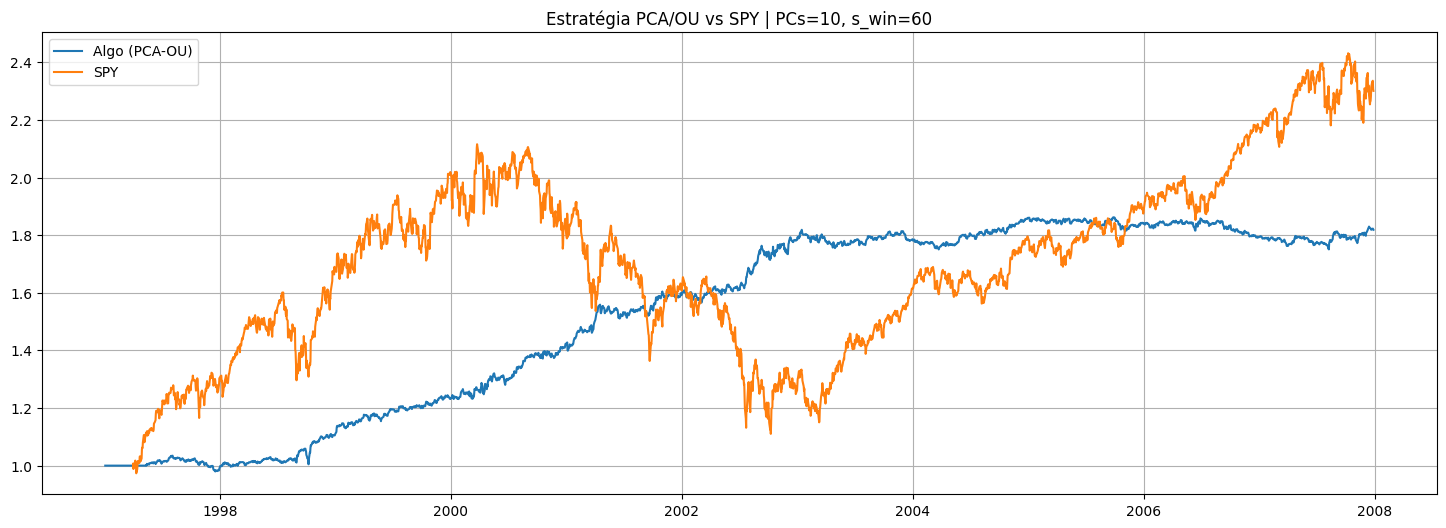

In [21]:
# Melhor (sem drift)
results2 = pca_portfolio_spy_hedge(
    returns=returns,
    returns_bench=returns_spy,
    benchmark="SPY",
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
    use_drift=False
)

In [22]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net2 = results2['ret_net']
stats2 = stats_from_returns(ret_net2)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats2.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")



PERFORMANCE DA ESTRATÉGIA (1999-2007)
  CAGR      :     0.0560 (   5.60%)
  Vol       :     0.0489 (   4.89%)
  Sharpe    :     1.1455 ( 114.55%)
  MaxDD     :    -0.0599 (  -5.99%)



Tempo : 1997-04-29 00:00:00
Tempo : 1997-04-30 00:00:00
Tempo : 1997-05-01 00:00:00
Tempo : 1997-05-02 00:00:00
Tempo : 1997-05-05 00:00:00
Tempo : 1997-05-06 00:00:00
Tempo : 1997-05-07 00:00:00
Tempo : 1997-05-08 00:00:00
Tempo : 1997-05-09 00:00:00
Tempo : 1997-05-12 00:00:00
Tempo : 1997-05-13 00:00:00
Tempo : 1997-05-14 00:00:00
Tempo : 1997-05-15 00:00:00
Tempo : 1997-05-16 00:00:00
Tempo : 1997-05-19 00:00:00
Tempo : 1997-05-20 00:00:00
Tempo : 1997-05-21 00:00:00
Tempo : 1997-05-22 00:00:00
Tempo : 1997-05-23 00:00:00
Tempo : 1997-05-27 00:00:00
Tempo : 1997-05-28 00:00:00
Tempo : 1997-05-29 00:00:00
Tempo : 1997-05-30 00:00:00
Tempo : 1997-06-02 00:00:00
Tempo : 1997-06-03 00:00:00
Tempo : 1997-06-04 00:00:00
Tempo : 1997-06-05 00:00:00
Tempo : 1997-06-06 00:00:00
Tempo : 1997-06-09 00:00:00
Tempo : 1997-06-10 00:00:00
Tempo : 1997-06-11 00:00:00
Tempo : 1997-06-12 00:00:00
Tempo : 1997-06-13 00:00:00
Tempo : 1997-06-16 00:00:00
Tempo : 1997-06-17 00:00:00
Tempo : 1997-06-18 0

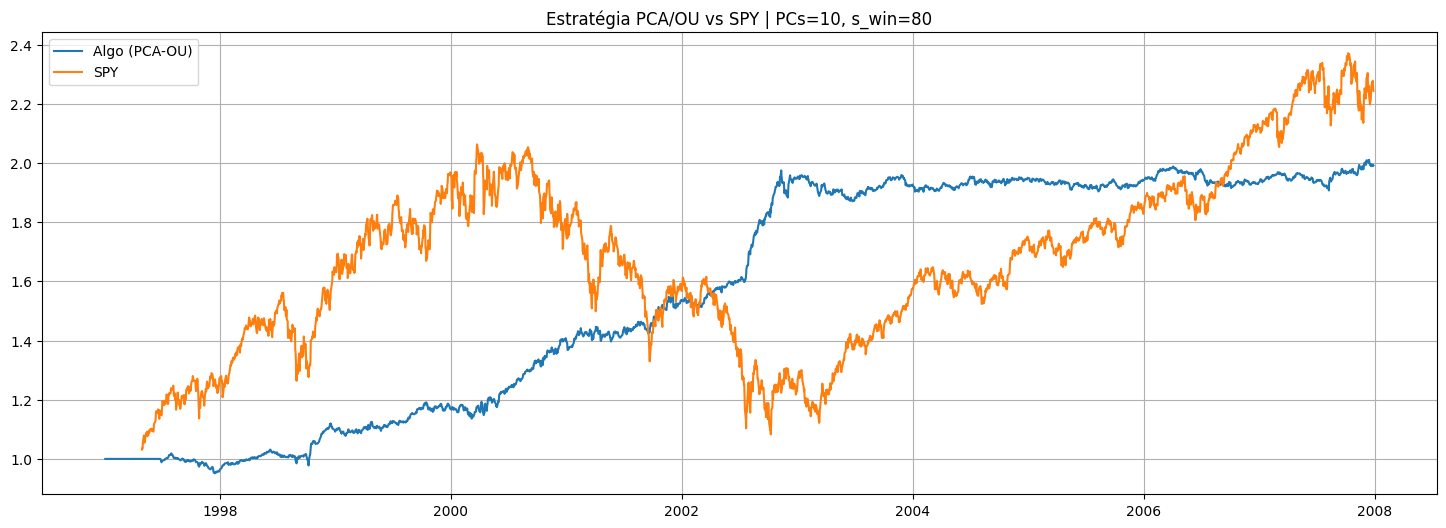

In [23]:
# Melhor (com drift)
results2 = pca_portfolio_spy_hedge(
    returns=returns,
    returns_bench=returns_spy,
    benchmark="SPY",
    num_pc=10,
    s_win=80,
    ma_window=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
    use_drift=True
)

In [24]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net2 = results2['ret_net']
stats2 = stats_from_returns(ret_net2)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats2.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")



PERFORMANCE DA ESTRATÉGIA (1999-2007)
  CAGR      :     0.0648 (   6.48%)
  Vol       :     0.0531 (   5.31%)
  Sharpe    :     1.2217 ( 122.17%)
  MaxDD     :    -0.0662 (  -6.62%)



In [25]:
adj_map2 = results2['adj_map']
adj_map2

{'MMM': -0.19618157376050985,
 'AOS': -0.08838289532144525,
 'ABT': -0.06702894013144166,
 'ADBE': -0.06854609548264796,
 'AES': -0.16135247074939504,
 'AFL': -0.06135248145033824,
 'APD': -0.06241000203549143,
 'ALB': -0.16758902918539284,
 'LNT': 0.13071464093613022,
 'ALL': -0.1734172286590072,
 'MO': 0.14669190957651465,
 'AEP': 0.0559734760346453,
 'AXP': 0.002613260839406968,
 'AIG': -0.17897541171585513,
 'AME': -0.11676487972130559,
 'AMGN': -0.18452199035343822,
 'APH': 0.0005980166375007035,
 'ADI': -0.16253408108066966,
 'AON': 0.2508855749283843,
 'APA': -0.384668878630995,
 'AAPL': 0.0063710832470750605,
 'AMAT': -0.05848725219657437,
 'ACGL': -0.023966708294264623,
 'ADM': -0.4596944824566286,
 'AJG': 0.09995686689378953,
 'T': -0.7163222051023012,
 'ATO': -0.22037406678249782,
 'ADSK': -0.23055112163847724,
 'ADP': -0.10023112015324137,
 'AZO': 0.1899799941344951,
 'AVB': -0.1117179412081265,
 'AVY': -0.01989117544973765,
 'BKR': -0.2854644250090996,
 'BALL': -0.16261266

### Testando com PC variáveis e Thresholdes variáveis

Tempo : 1999-03-29 00:00:00
Tempo : 1999-03-30 00:00:00
Tempo : 1999-03-31 00:00:00
Tempo : 1999-04-01 00:00:00
Tempo : 1999-04-05 00:00:00
Tempo : 1999-04-06 00:00:00
Tempo : 1999-04-07 00:00:00
Tempo : 1999-04-08 00:00:00
Tempo : 1999-04-09 00:00:00
Tempo : 1999-04-12 00:00:00
Tempo : 1999-04-13 00:00:00
Tempo : 1999-04-14 00:00:00
Tempo : 1999-04-15 00:00:00
Tempo : 1999-04-16 00:00:00
Tempo : 1999-04-19 00:00:00
Tempo : 1999-04-20 00:00:00
Tempo : 1999-04-21 00:00:00
Tempo : 1999-04-22 00:00:00
Tempo : 1999-04-23 00:00:00
Tempo : 1999-04-26 00:00:00
Tempo : 1999-04-27 00:00:00
Tempo : 1999-04-28 00:00:00
Tempo : 1999-04-29 00:00:00
Tempo : 1999-04-30 00:00:00
Tempo : 1999-05-03 00:00:00
Tempo : 1999-05-04 00:00:00
Tempo : 1999-05-05 00:00:00
Tempo : 1999-05-06 00:00:00
Tempo : 1999-05-07 00:00:00
Tempo : 1999-05-10 00:00:00
Tempo : 1999-05-11 00:00:00
Tempo : 1999-05-12 00:00:00
Tempo : 1999-05-13 00:00:00
Tempo : 1999-05-14 00:00:00
Tempo : 1999-05-17 00:00:00
Tempo : 1999-05-18 0

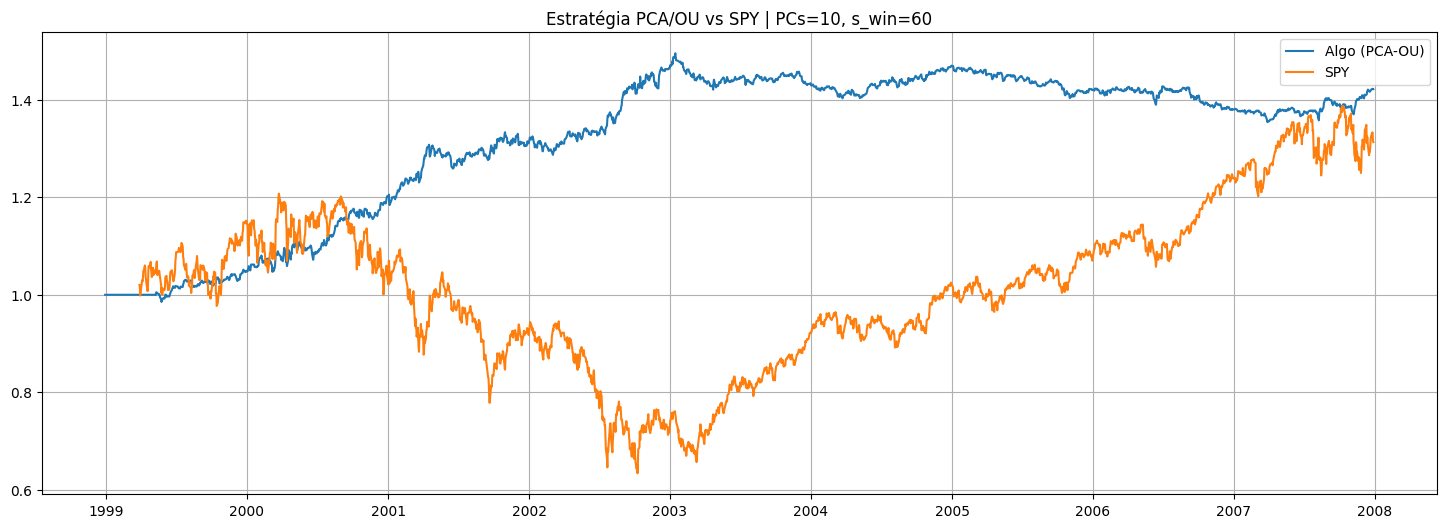

In [11]:
# Melhor
returns0 = returns.loc["1998-12-30":"2007-12-28"]
returns_spy0 = returns_spy.loc["1998-12-30":"2007-12-28"]

results3 = pca_portfolio_spy_var(
    returns=returns0,
    returns_spy=returns_spy0,
    num_pc=10,
    s_win=60,
    adaptive_thresholds=True,
    adaptive_window=252,
    percentile_open=0.10,
    percentile_close_short=0.45,
    percentile_close_long=0.50,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True
)

In [ ]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net3 = results3['ret_net']
stats3 = stats_from_returns(ret_net3)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats3.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")

# =============================================================================
# 4. ANÁLISE DE NEUTRALIDADE ⭐ NOVO
# =============================================================================

analysis_results3 = analyze_strategy(
    algo_weights=results3['algo_weights'],
    betas=results3['betas'],
    ret_net=results3['ret_net'],
    Factor_PCA=results3['Factor_PCA'],
    pcs=results3['pcs'],
    plot=True,
    title_prefix="[1999-2007] "
)

# =============================================================================
# 5. ANÁLISE POR SUBPERÍODOS (OPCIONAL)
# =============================================================================

print("\n" + "📅 "*35)
print("ANÁLISE POR SUBPERÍODOS")
print("📅 "*35 + "\n")

subperiods3 = [
    ("1999-2002", "1999-01-01", "2002-12-31"),
    ("2003-2007", "2003-01-01", "2007-12-31"),
]

for label, start, end in subperiods3:
    print(f"\n{'='*70}")
    print(f"Subperíodo: {label}")
    print(f"{'='*70}")
    
    mask = (ret_net3.index >= start) & (ret_net3.index <= end)
    ret_sub = ret_net3[mask]

    if len(ret_sub) < 100:
        print("⚠️  Dados insuficientes")
        continue
    
    stats_sub = stats_from_returns(ret_sub)
    for k, v in stats_sub.items():
        print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")

Tempo : 1999-03-29 00:00:00
Tempo : 1999-03-30 00:00:00
Tempo : 1999-03-31 00:00:00
Tempo : 1999-04-01 00:00:00
Tempo : 1999-04-05 00:00:00
Tempo : 1999-04-06 00:00:00
Tempo : 1999-04-07 00:00:00
Tempo : 1999-04-08 00:00:00
Tempo : 1999-04-09 00:00:00
Tempo : 1999-04-12 00:00:00
Tempo : 1999-04-13 00:00:00
Tempo : 1999-04-14 00:00:00
Tempo : 1999-04-15 00:00:00
Tempo : 1999-04-16 00:00:00
Tempo : 1999-04-19 00:00:00
Tempo : 1999-04-20 00:00:00
Tempo : 1999-04-21 00:00:00
Tempo : 1999-04-22 00:00:00
Tempo : 1999-04-23 00:00:00
Tempo : 1999-04-26 00:00:00
Tempo : 1999-04-27 00:00:00
Tempo : 1999-04-28 00:00:00
Tempo : 1999-04-29 00:00:00
Tempo : 1999-04-30 00:00:00
Tempo : 1999-05-03 00:00:00
Tempo : 1999-05-04 00:00:00
Tempo : 1999-05-05 00:00:00
Tempo : 1999-05-06 00:00:00
Tempo : 1999-05-07 00:00:00
Tempo : 1999-05-10 00:00:00
Tempo : 1999-05-11 00:00:00
Tempo : 1999-05-12 00:00:00
Tempo : 1999-05-13 00:00:00
Tempo : 1999-05-14 00:00:00
Tempo : 1999-05-17 00:00:00
Tempo : 1999-05-18 0

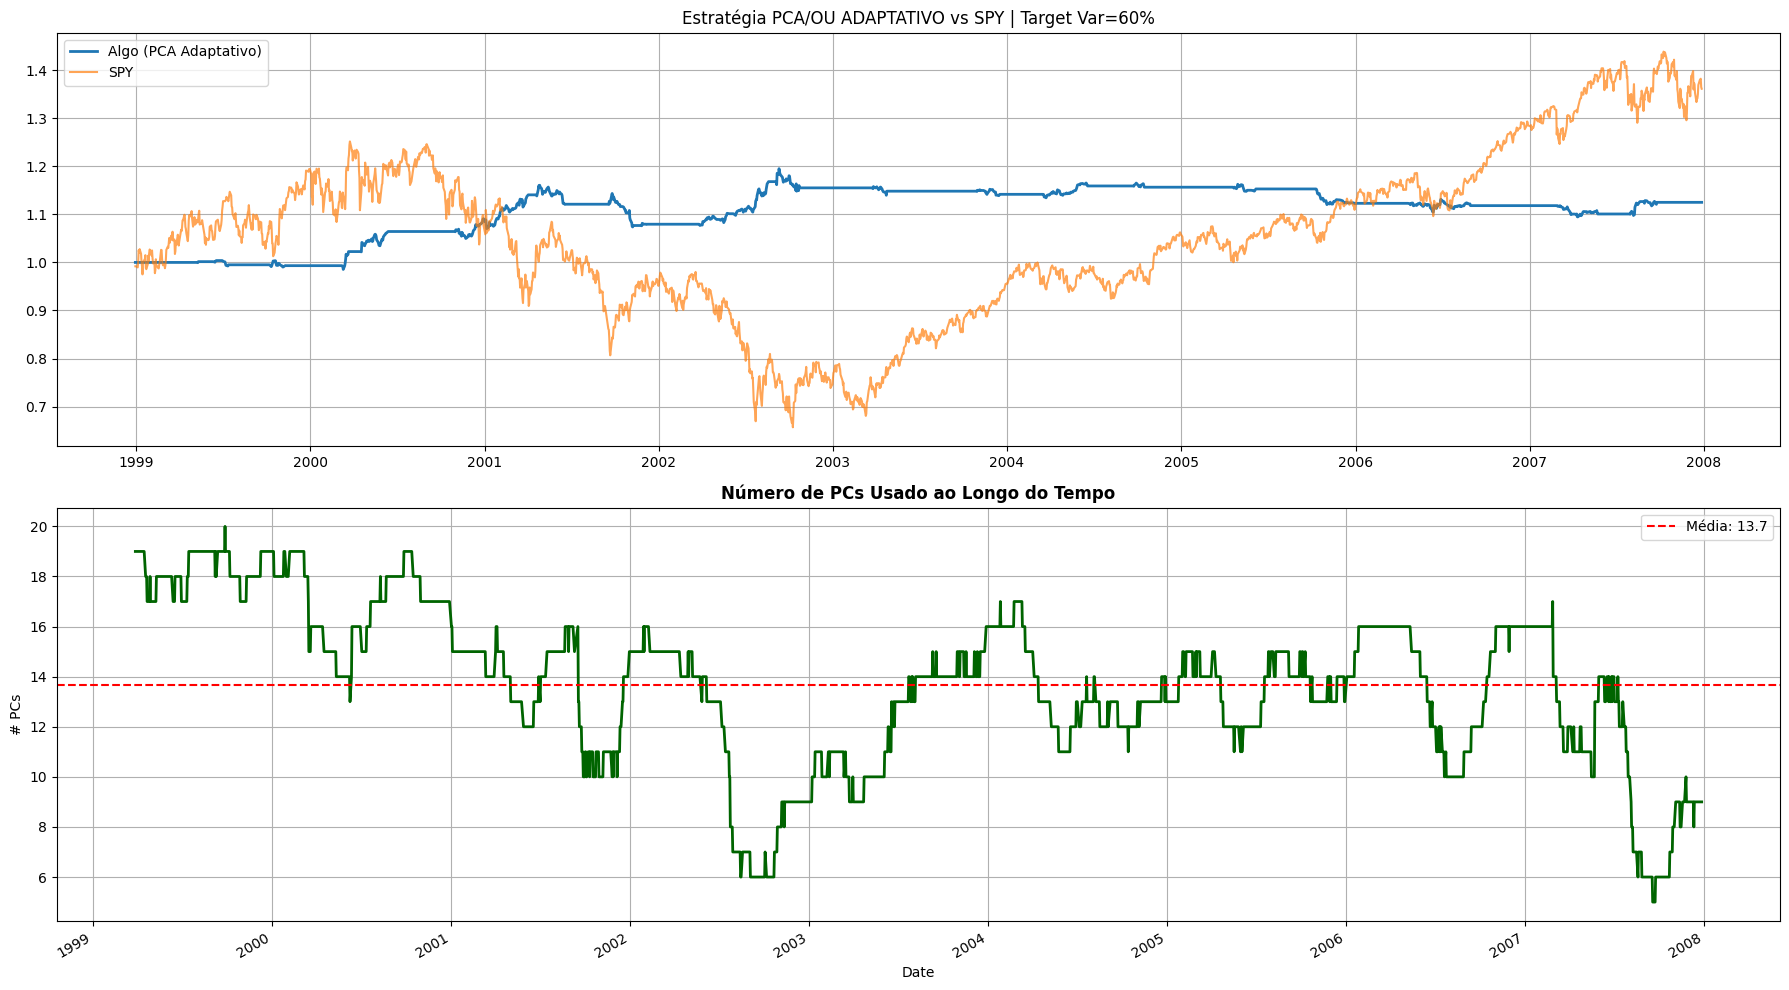

In [6]:
returns0 = returns.loc["1998-12-30":"2007-12-28"]
returns_spy0 = returns_spy.loc["1998-12-30":"2007-12-28"]

results4 = pca_portfolio_spy_adaptive_pcs(
    returns = returns0,
    returns_spy = returns_spy0,
    variance_target = 0.60,  
    min_pcs = 5,
    max_pcs = 35,
    s_win = 60,
    adaptive_thresholds = False,
    adaptive_window = 252,
    percentile_open = 0.15,
    percentile_close_short = 0.35,
    percentile_close_long = 0.45,
    # thresholds fixos
    sbo = 1.25,
    sso = 1.25,
    sbc = 0.50,
    ssc = 0.50,
    eps_cost = 0.0005,
    rebalanceamento_dias = 1,
    plot = True,
)

In [ ]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net4 = results4['ret_net']
stats4 = stats_from_returns(ret_net4)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats4.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")

# =============================================================================
# 4. ANÁLISE DE NEUTRALIDADE ⭐ NOVO
# =============================================================================

analysis_results4 = analyze_strategy(
    algo_weights=results4['algo_weights'],
    betas=results4['betas'],
    ret_net=results4['ret_net'],
    Factor_PCA=results4['Factor_PCA'],
    pcs=results4['pcs'],
    plot=True,
    title_prefix="[1999-2007] "
)

# =============================================================================
# 5. ANÁLISE POR SUBPERÍODOS (OPCIONAL)
# =============================================================================

print("\n" + "📅 "*35)
print("ANÁLISE POR SUBPERÍODOS")
print("📅 "*35 + "\n")

subperiods4 = [
    ("1999-2002", "1999-01-01", "2002-12-31"),
    ("2003-2007", "2003-01-01", "2007-12-31"),
]

for label, start, end in subperiods4:
    print(f"\n{'='*70}")
    print(f"Subperíodo: {label}")
    print(f"{'='*70}")
    
    mask = (ret_net4.index >= start) & (ret_net4.index <= end)
    ret_sub = ret_net4[mask]

    if len(ret_sub) < 100:
        print("⚠️  Dados insuficientes")
        continue
    
    stats_sub = stats_from_returns(ret_sub)
    for k, v in stats_sub.items():
        print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")

Tempo : 1999-03-29 00:00:00
Tempo : 1999-03-30 00:00:00
Tempo : 1999-03-31 00:00:00
Tempo : 1999-04-01 00:00:00
Tempo : 1999-04-05 00:00:00
Tempo : 1999-04-06 00:00:00
Tempo : 1999-04-07 00:00:00
Tempo : 1999-04-08 00:00:00
Tempo : 1999-04-09 00:00:00
Tempo : 1999-04-12 00:00:00
Tempo : 1999-04-13 00:00:00
Tempo : 1999-04-14 00:00:00
Tempo : 1999-04-15 00:00:00
Tempo : 1999-04-16 00:00:00
Tempo : 1999-04-19 00:00:00
Tempo : 1999-04-20 00:00:00
Tempo : 1999-04-21 00:00:00
Tempo : 1999-04-22 00:00:00
Tempo : 1999-04-23 00:00:00
Tempo : 1999-04-26 00:00:00
Tempo : 1999-04-27 00:00:00
Tempo : 1999-04-28 00:00:00
Tempo : 1999-04-29 00:00:00
Tempo : 1999-04-30 00:00:00
Tempo : 1999-05-03 00:00:00
Tempo : 1999-05-04 00:00:00
Tempo : 1999-05-05 00:00:00
Tempo : 1999-05-06 00:00:00
Tempo : 1999-05-07 00:00:00
Tempo : 1999-05-10 00:00:00
Tempo : 1999-05-11 00:00:00
Tempo : 1999-05-12 00:00:00
Tempo : 1999-05-13 00:00:00
Tempo : 1999-05-14 00:00:00
Tempo : 1999-05-17 00:00:00
Tempo : 1999-05-18 0

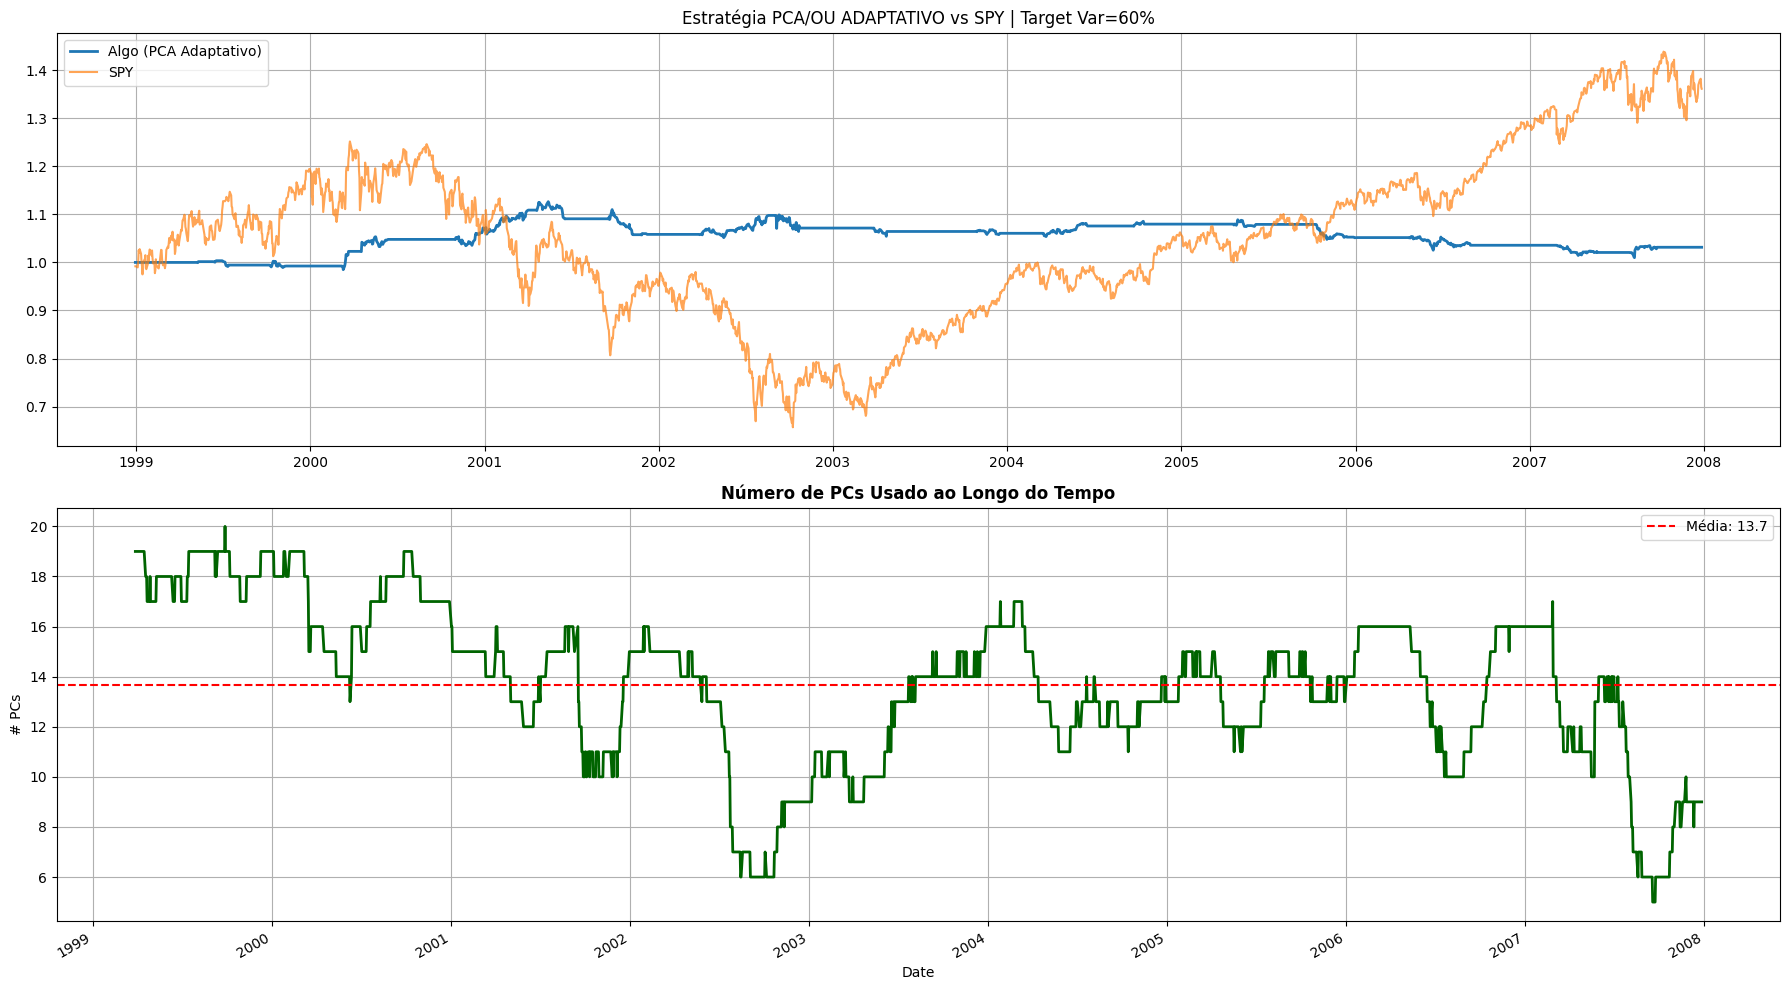

In [15]:
returns0 = returns.loc["1998-12-30":"2007-12-28"]
returns_spy0 = returns_spy.loc["1998-12-30":"2007-12-28"]

results5 = pca_portfolio_spy_adaptive_pcs(
    returns = returns0,
    returns_spy = returns_spy0,
    variance_target = 0.60,  
    min_pcs = 5,
    max_pcs = 35,
    s_win = 60,
    adaptive_thresholds = True,
    adaptive_window = 252,
    percentile_open = 0.15,
    percentile_close_short = 0.35,
    percentile_close_long = 0.45,
    # thresholds fixos
    sbo = 1.25,
    sso = 1.25,
    sbc = 0.50,
    ssc = 0.50,
    eps_cost = 0.0005,
    rebalanceamento_dias = 1,
    plot = True,
)

### Longo prazo

In [7]:
# Carregar dados
#start_date = "1997-01-02"
#end_date = "2007-12-31"

data_longa = pd.read_csv("dados_1997_2025.csv", index_col=0)
returns_longa = data_longa.pct_change()

returns_longa.dropna(inplace=True,axis=0, how='all')
returns_longa.dropna(inplace=True,axis=1, how='any')

data_spy_longa = yf.download("SPY", start="1997-01-02", end="2025-12-31", auto_adjust=True)["Close"]
data_spy_longa.index = pd.to_datetime(data_spy_longa.index)
data_spy_longa = data_spy_longa.sort_index()

# Garantir que ambos os DataFrames tenham índices coerentes e ordenados (sem timezone)
returns_spy_longa = data_spy_longa.pct_change()
returns_longa.index     = pd.to_datetime(returns_longa.index).tz_localize(None)
returns_spy_longa.index = pd.to_datetime(returns_spy_longa.index).tz_localize(None)
returns_longa     = returns_longa.sort_index()
returns_spy_longa = returns_spy_longa.sort_index()

C:\Users\savio\AppData\Local\Temp\ipykernel_2388\156121036.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_longa = data_longa.pct_change()
[*********************100%***********************]  1 of 1 completed


In [12]:
# # verificando dados ruins
# bad_tickers2 = []

# for col in data_longa.columns:
#     p = data_longa[col]
#     if p.min() <= 0:
#         bad_tickers2.append(col)
#         continue
#     if (p.max() / p.min()) > 1e3:  # variação absurda de escala
#         bad_tickers2.append(col)

# data_longa = data_longa.drop(columns=bad_tickers2, errors="ignore")
# returns_longa = returns_longa.drop(columns=bad_tickers2, errors="ignore")

# bad_tickers2

Tempo : 1997-04-01 00:00:00
Tempo : 1997-04-02 00:00:00
Tempo : 1997-04-03 00:00:00
Tempo : 1997-04-04 00:00:00
Tempo : 1997-04-07 00:00:00
Tempo : 1997-04-08 00:00:00
Tempo : 1997-04-09 00:00:00
Tempo : 1997-04-10 00:00:00
Tempo : 1997-04-11 00:00:00
Tempo : 1997-04-14 00:00:00
Tempo : 1997-04-15 00:00:00
Tempo : 1997-04-16 00:00:00
Tempo : 1997-04-17 00:00:00
Tempo : 1997-04-18 00:00:00
Tempo : 1997-04-21 00:00:00
Tempo : 1997-04-22 00:00:00
Tempo : 1997-04-23 00:00:00
Tempo : 1997-04-24 00:00:00
Tempo : 1997-04-25 00:00:00
Tempo : 1997-04-28 00:00:00
Tempo : 1997-04-29 00:00:00
Tempo : 1997-04-30 00:00:00
Tempo : 1997-05-01 00:00:00
Tempo : 1997-05-02 00:00:00
Tempo : 1997-05-05 00:00:00
Tempo : 1997-05-06 00:00:00
Tempo : 1997-05-07 00:00:00
Tempo : 1997-05-08 00:00:00
Tempo : 1997-05-09 00:00:00
Tempo : 1997-05-12 00:00:00
Tempo : 1997-05-13 00:00:00
Tempo : 1997-05-14 00:00:00
Tempo : 1997-05-15 00:00:00
Tempo : 1997-05-16 00:00:00
Tempo : 1997-05-19 00:00:00
Tempo : 1997-05-20 0

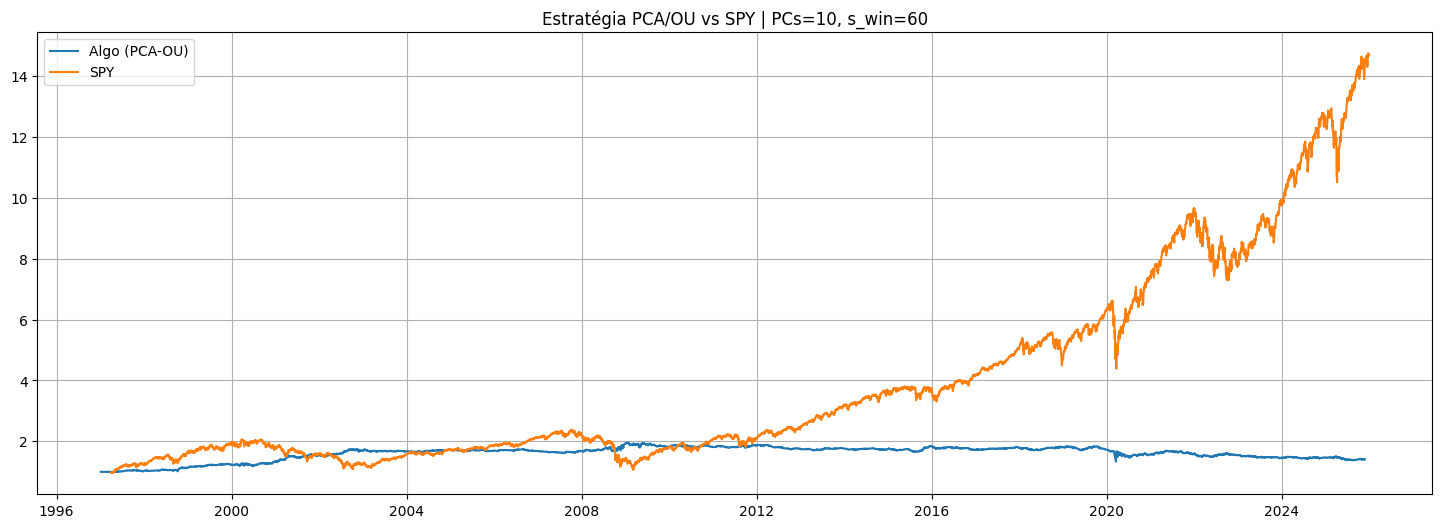

In [ ]:
# Melhor longo (sem drift)

results6 = pca_portfolio_spy_hedge(
    returns=returns_longa,
    returns_bench=returns_spy_longa,
    benchmark="SPY",
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
    use_drift=False
)


PERFORMANCE DA ESTRATÉGIA (1997-2025)
  CAGR      :     0.0119 (   1.19%)
  Vol       :     0.0739 (   7.39%)
  Sharpe    :     0.1614 (  16.14%)
  MaxDD     :    -0.3192 ( -31.92%)


🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 
ANÁLISE DE NEUTRALIDADE DA ESTRATÉGIA
🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 


[1/2] Calculando exposição beta agregada...

ESTATÍSTICAS DE EXPOSIÇÃO BETA AGREGADA
         Mean     Std     Min     Max  Mean_Abs
eig1   0.0011  0.0688 -0.5132  0.4448    0.0487
eig2  -0.0031  0.0832 -0.3985  0.4903    0.0596
eig3   0.0009  0.0743 -0.3152  0.3800    0.0552
eig4   0.0030  0.0572 -0.2219  0.2446    0.0447
eig5   0.0040  0.0596 -0.2256  0.2597    0.0454
eig6  -0.0013  0.0604 -0.2577  0.2768    0.0463
eig7  -0.0056  0.0602 -0.3659  0.2327    0.0457
eig8  -0.0004  0.0584 -0.2659  0.2560    0.0440
eig9  -0.0016  0.0572 -0.2526  0.3032    0.0436
eig10  0.0034  0.0565 -0.2441  0.4926    0.0436

📊 Interpretação:
  

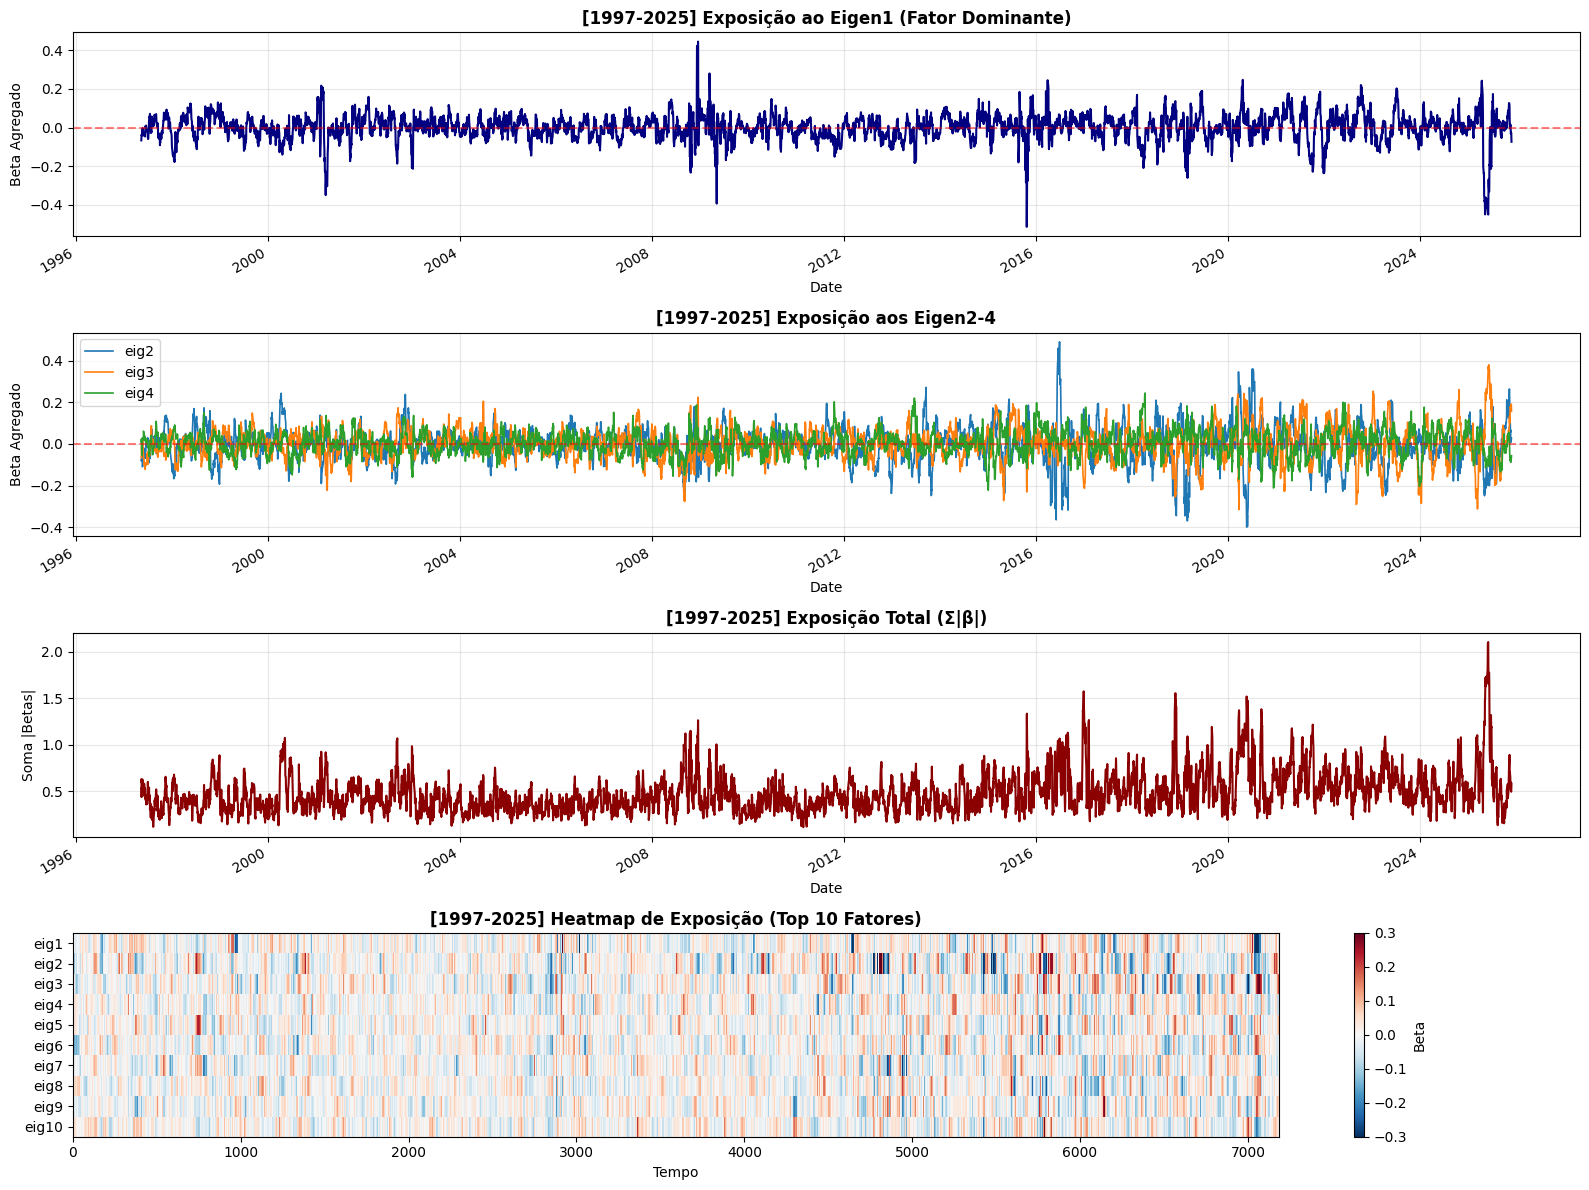


[2/2] Regredindo PnL contra fatores...

REGRESSÃO: RETORNO DA ESTRATÉGIA vs FATORES PCA
  R² (variância explicada por fatores): 0.0136 (1.36%)
  Alpha anualizado (excesso de retorno):  0.0160 (1.60%)
  Alpha diário médio:                      0.000063

  Beta médio (|valor|):                    0.0443
  Beta máximo (|valor|):                   0.0798 (fator: eig5)

📊 Interpretação:
  ✅ EXCELENTE: R² < 5% → Estratégia é genuinamente market-neutral!
     A maior parte do retorno vem de alpha idiossincrático.

  ⚠️  Alpha marginal (1.60%/ano)


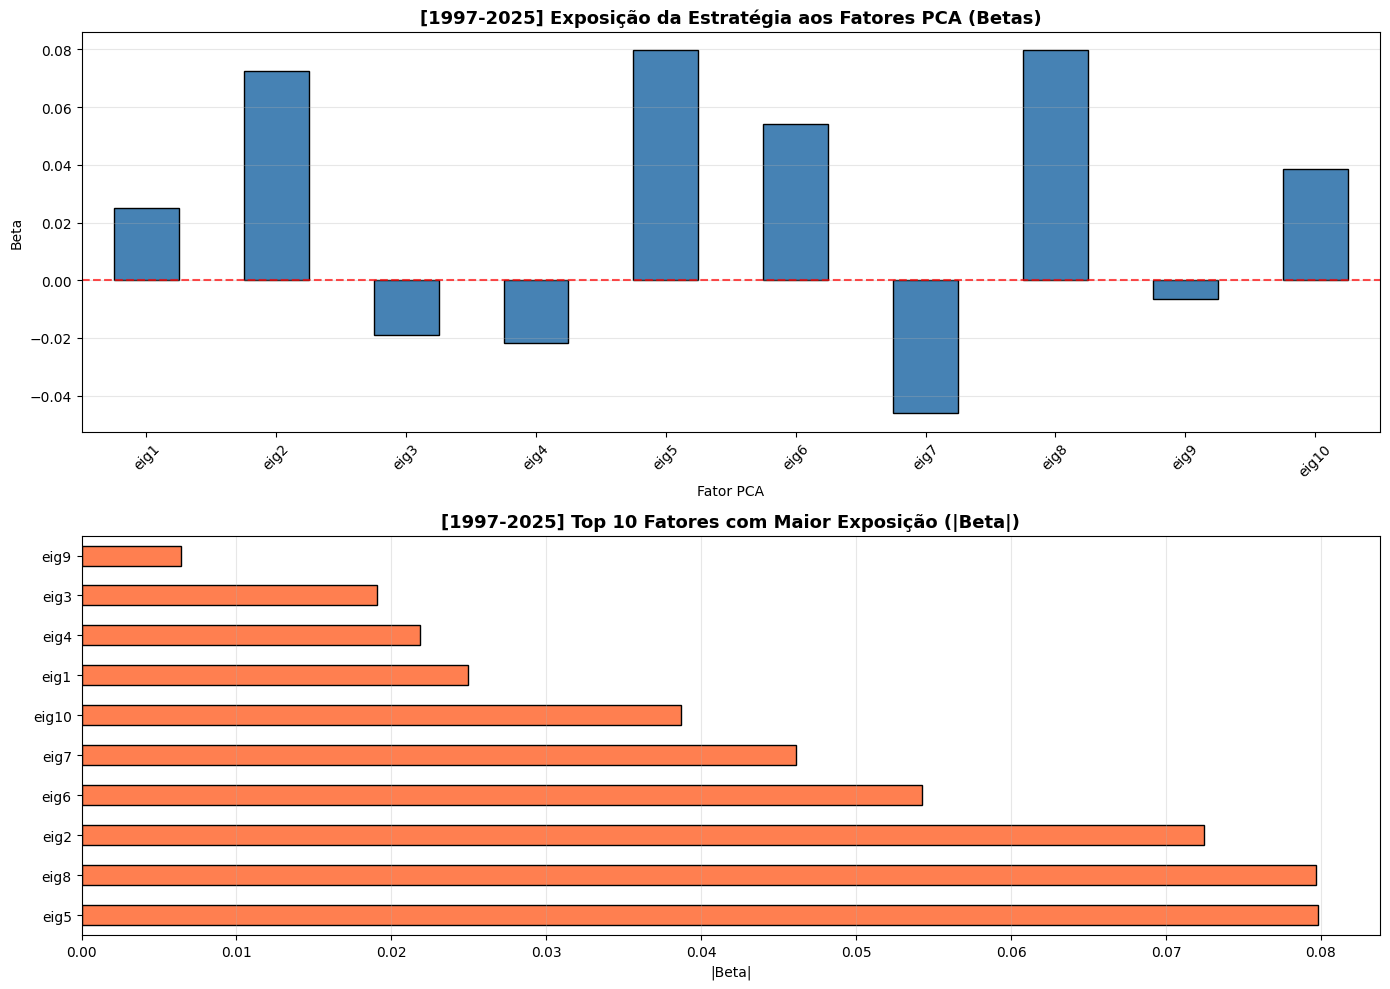


✅ Análise concluída!


📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 
ANÁLISE POR SUBPERÍODOS
📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 


Subperíodo: 1997-2002
  CAGR      :     0.0925 (   9.25%)
  Vol       :     0.0766 (   7.66%)
  Sharpe    :     1.2069 ( 120.69%)
  MaxDD     :    -0.0799 (  -7.99%)

Subperíodo: 2003-2007
  CAGR      :    -0.0022 (  -0.22%)
  Vol       :     0.0395 (   3.95%)
  Sharpe    :    -0.0564 (  -5.64%)
  MaxDD     :    -0.0795 (  -7.95%)

Subperíodo: 2008-2012
  CAGR      :     0.0094 (   0.94%)
  Vol       :     0.0893 (   8.93%)
  Sharpe    :     0.1057 (  10.57%)
  MaxDD     :    -0.1155 ( -11.55%)

Subperíodo: 2013-2019
  CAGR      :    -0.0024 (  -0.24%)
  Vol       :     0.0477 (   4.77%)
  Sharpe    :    -0.0497 (  -4.97%)
  MaxDD     :    -0.0796 (  -7.96%)

Subperíodo: 2020-2025
  CAGR      :    -0.0344 (  -3.44%)
  Vol       :     0.1000 (  10.00%)
  Sharpe    :    -0.3438 ( -34.38%)
  MaxDD   

In [18]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net6 = results6['ret_net']
stats6 = stats_from_returns(ret_net6)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1997-2025)")
print("="*70)
for k, v in stats6.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")

# =============================================================================
# 4. ANÁLISE DE NEUTRALIDADE ⭐
# =============================================================================

analysis_results6 = analyze_strategy(
    algo_weights=results6['algo_weights'],
    betas=results6['betas'],
    ret_net=results6['ret_net'],
    Factor_PCA=results6['Factor_PCA'],
    pcs=results6['pcs'],
    plot=True,
    title_prefix="[1997-2025] "
)

# =============================================================================
# 5. ANÁLISE POR SUBPERÍODOS (OPCIONAL)
# =============================================================================

print("\n" + "📅 "*35)
print("ANÁLISE POR SUBPERÍODOS")
print("📅 "*35 + "\n")

subperiods6 = [
    ("1997-2002", "1997-01-01", "2002-12-31"),
    ("2003-2007", "2003-01-01", "2007-12-31"),
    ("2008-2012", "2008-01-01", "2012-12-31"),
    ("2013-2019", "2013-01-01", "2019-12-31"),
    ("2020-2025", "2020-01-01", "2025-12-31"),
]

for label, start, end in subperiods6:
    print(f"\n{'='*70}")
    print(f"Subperíodo: {label}")
    print(f"{'='*70}")
    
    mask = (ret_net6.index >= start) & (ret_net6.index <= end)
    ret_sub = ret_net6[mask]

    if len(ret_sub) < 100:
        print("⚠️  Dados insuficientes")
        continue
    
    stats_sub = stats_from_returns(ret_sub)
    for k, v in stats_sub.items():
        print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")

In [ ]:
# Melhor longo (com drift)

results6 = pca_portfolio_spy_hedge(
    returns=returns_longa,
    returns_bench=returns_spy_longa,
    benchmark="SPY",
    num_pc=10,
    s_win=80,
    ma_window=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
    use_drift=True
)

### Otimizador

In [10]:
# --------------------------
# Métrica
# --------------------------
def sharpe_ann(r: pd.Series, trading_days: int = 252) -> float:
    r = r.dropna()
    if len(r) < 60:
        return np.nan
    vol = r.std(ddof=1)
    if vol == 0 or not np.isfinite(vol):
        return np.nan
    return float(np.sqrt(trading_days) * r.mean() / vol)


def score_strategy(ret_net: pd.Series, trading_days: int = 252) -> float:
    r = ret_net.dropna()
    if len(r) < 60:
        return -np.inf
    sh = sharpe_ann(r, trading_days=trading_days)
    if np.isnan(sh):
        return -np.inf
    return sh


# --------------------------
# Rolling Walk-forward splits
# --------------------------
def walk_forward_splits_rolling(
    index: pd.Index,
    *,
    n_folds: int = 4,
    train_size: int = 252 * 2,   # 2 anos
    test_size: int = 252,        # 1 ano
    step_size: int | None = None,  # avanço entre folds
    purge: int = 0,
):
    """
    Rolling walk-forward:

    Fold k:
      train: [train_start : train_end)
      purge: [train_end : test_start)
      test : [test_start : test_end)

    Retorna lista de (train_start, train_end, test_start, test_end) (posições inteiras).
    """
    n = len(index)
    if step_size is None:
        step_size = test_size  # anda 1 ano por fold, por default

    splits = []
    train_start = 0

    for k in range(n_folds):
        train_end = train_start + train_size
        test_start = train_end + purge
        test_end = test_start + test_size

        if test_end > n:
            break

        splits.append((train_start, train_end, test_start, test_end))
        train_start += step_size

    return splits


# --------------------------
# Avaliação por folds
# --------------------------
def eval_params_rolling(
    returns: pd.DataFrame,
    returns_bench: pd.Series | pd.DataFrame,
    params: dict,
    trial: optuna.Trial | None = None,
    *,
    n_folds: int = 4,
    train_size: int = 252 * 2,
    test_size: int = 252,
    step_size: int | None = None,
):
    # alinhar globalmente (remove datas que não existem em ambos)
    common = returns.index.intersection(returns_bench.index)
    returns = returns.loc[common]
    returns_bench = returns_bench.loc[common]

    # purge depende das janelas
    s_win = int(params["s_win"])
    ma_window = int(params["ma_window"])
    purge = max(s_win, ma_window) + 5

    # gerar splits rolling
    splits = walk_forward_splits_rolling(
        returns.index,
        n_folds=n_folds,
        train_size=train_size,
        test_size=test_size,
        step_size=step_size,
        purge=purge,
    )
    if not splits:
        return -np.inf

    fold_scores: list[float] = []

    for k, (train_start, train_end, test_start, test_end) in enumerate(splits):
    
        sub_returns = returns.iloc[train_start:test_end]
        sub_bench = returns_bench.iloc[train_start:test_end]

        # alinhamento dentro do fold
        if isinstance(sub_bench, pd.Series):
            aligned = sub_returns.join(sub_bench.rename("bench"), how="inner")
            sub_returns = aligned[sub_returns.columns]
            sub_bench = aligned["bench"]
        else:
            aligned = sub_returns.join(sub_bench, how="inner")
            sub_returns = aligned[sub_returns.columns]
            sub_bench = aligned[sub_bench.columns]

        test_idx = returns.index[test_start:test_end]
        test_idx_inner = aligned.index.intersection(test_idx)

        # se o join matou muita coisa, evita fold inválido
        if len(test_idx_inner) < 60:
            return -np.inf

        #  roda o backtest no bloco 
        try:
            res = pca_portfolio_spy_hedge(
                returns=sub_returns,
                returns_bench=sub_bench,
                benchmark=params.get("benchmark", "BENCH"),
                num_pc=int(params["num_pc"]),
                s_win=s_win,
                sbo=float(params["sbo"]),
                sso=float(params["sso"]),
                sbc=float(params["sbc"]),
                ssc=float(params["ssc"]),
                eps_cost=float(params["eps_cost"]),
                rebalanceamento_dias=int(params["rebalanceamento_dias"]),
                kappa_min=float(params["kappa_min"]),
                plot=False,
                use_drift=bool(params["use_drift"]),
                ma_window=ma_window,
                verbose=False,
            )
        except Exception:
            return -np.inf

        # score só no teste
        ret_net_test = res["ret_net"].reindex(test_idx_inner).dropna()
        fold_score = score_strategy(ret_net_test)
        fold_scores.append(fold_score)

        # pruning
        if trial is not None:
            trial.report(float(np.mean(fold_scores)), step=k)
            if trial.should_prune():
                raise optuna.TrialPruned()

    return float(np.mean(fold_scores))


# --------------------------
# Optuna
# --------------------------
def optimize_optuna(
    returns: pd.DataFrame,
    returns_bench: pd.Series | pd.DataFrame,
    *,
    n_trials: int = 60,
    n_folds: int = 4,
    train_size: int = 252 * 2,
    test_size: int = 252,
    step_size: int | None = None,
    seed: int = 42,
    study_name: str = "pca_hedge_long_v1",
    storage: str = "sqlite:///optuna_usa.db",
):
    """
    Otimiza parâmetros maximizando Sharpe médio OOS em rolling walk-forward.
    """

    def objective(trial: optuna.Trial) -> float:
        now = time.strftime("%H:%M:%S")
        pid = os.getpid()
        tname = threading.current_thread().name
        print(f"[{now}] START trial={trial.number} pid={pid} thread={tname}")

        # --------------------------
        # Hiperparâmetros
        # --------------------------
        s_win = trial.suggest_int("s_win", 60, 250, step=5)

        hi = min(120, s_win - 2)
        if (hi - 20) % 2 != 0:
            hi -= 1
        ma_window = trial.suggest_int("ma_window", 20, hi, step=2)

        sbo = trial.suggest_float("sbo", 0.8, 2.5)
        sso = trial.suggest_float("sso", 0.8, 2.5)

        sbc = trial.suggest_float("sbc", 0.1, sso - 0.05)  # close short < open short
        ssc = trial.suggest_float("ssc", 0.1, sbo - 0.05)  # close long  < open long

        kappa_min = trial.suggest_float("kappa_min", 1.0, 15.0)
        num_pc = trial.suggest_int("num_pc", 8, 20)
        rebalanceamento_dias = trial.suggest_int("rebalanceamento_dias", 1, 30)

        params = dict(
            benchmark="IBOV",
            num_pc=num_pc,
            s_win=s_win,
            ma_window=ma_window,
            sbo=sbo,
            sso=sso,
            sbc=sbc,
            ssc=ssc,
            eps_cost=0.0005,
            rebalanceamento_dias=rebalanceamento_dias,
            kappa_min=kappa_min,
            plot=False,
            use_drift=True,
            verbose=False,
        )

        return eval_params_rolling(
            returns,
            returns_bench,
            params,
            trial=trial,
            n_folds=n_folds,
            train_size=train_size,
            test_size=test_size,
            step_size=step_size,
        )

    sampler = optuna.samplers.TPESampler(seed=seed)
    pruner = optuna.pruners.HyperbandPruner(
        min_resource=1,
        max_resource=n_folds,
        reduction_factor=3,
    )

    study = optuna.create_study(
        direction="maximize",
        sampler=sampler,
        pruner=pruner,
        study_name=study_name,
        storage=storage,
        load_if_exists=True,
    )

    study.optimize(objective, n_trials=n_trials, n_jobs=1, show_progress_bar=True)
    return study

In [11]:
returns_train = returns_longa.loc["1997-01-01":"2004-12-31"]  # 7 anos
bench_train   = returns_spy_longa.loc["1997-01-01":"2004-12-31"]

returns_opt = returns_longa.loc["2005-01-01":"2025-12-31"]
bench_opt   = returns_spy_longa.loc["2005-01-01":"2025-12-31"]

In [13]:
study = optimize_optuna(
    returns_train,
    bench_train,
    n_trials=70,
    n_folds=4,
    train_size=252*2,
    test_size=252,
    step_size=252,
    study_name="optuna_for_usa"   
)

best = study.best_params
print(best)

[I 2026-02-23 10:41:39,874] A new study created in RDB with name: optuna_for_usa
  0%|          | 0/70 [00:00<?, ?it/s]

[10:41:39] START trial=0 pid=2388 thread=MainThread


Best trial: 0. Best value: 0.477089:   1%|▏         | 1/70 [57:18<65:54:35, 3438.77s/it]

[I 2026-02-23 11:38:58,634] Trial 0 finished with value: 0.47708885411572877 and parameters: {'s_win': 130, 'ma_window': 116, 'sbo': 2.044389701079389, 'sso': 1.8177194231349623, 'sbc': 0.3601953170369613, 'ssc': 0.39551441274972154, 'kappa_min': 1.8131705703547925, 'num_pc': 19, 'rebalanceamento_dias': 19}. Best is trial 0 with value: 0.47708885411572877.
[11:38:58] START trial=1 pid=2388 thread=MainThread


Best trial: 0. Best value: 0.477089:   3%|▎         | 2/70 [1:54:23<64:48:06, 3430.69s/it]

...

[I 2026-02-26 00:33:47,872] Trial 67 finished with value: 2.1656266433588467 and parameters: {'s_win': 250, 'ma_window': 28, 'sbo': 1.5170368833554817, 'sso': 1.5131488548308256, 'sbc': 1.1017814653093532, 'ssc': 1.1803503810075742, 'kappa_min': 2.3771508677085706, 'num_pc': 16, 'rebalanceamento_dias': 2}. Best is trial 67 with value: 2.1656266433588467.
[00:33:47] START trial=68 pid=2388 thread=MainThread


Best trial: 67. Best value: 2.16563:  99%|█████████▊| 69/70 [63:02:15<1:09:56, 4196.47s/it]

[I 2026-02-26 01:43:55,157] Trial 68 pruned. 
[01:43:55] START trial=69 pid=2388 thread=MainThread


Best trial: 67. Best value: 2.16563: 100%|██████████| 70/70 [63:35:34<00:00, 3270.49s/it]  

[I 2026-02-26 02:17:14,498] Trial 69 pruned. 
{'s_win': 250, 'ma_window': 28, 'sbo': 1.5170368833554817, 'sso': 1.5131488548308256, 'sbc': 1.1017814653093532, 'ssc': 1.1803503810075742, 'kappa_min': 2.3771508677085706, 'num_pc': 16, 'rebalanceamento_dias': 2}


Tempo : 2005-12-29 00:00:00
Tempo : 2005-12-30 00:00:00
Tempo : 2006-01-03 00:00:00
Tempo : 2006-01-04 00:00:00
Tempo : 2006-01-05 00:00:00
Tempo : 2006-01-06 00:00:00
Tempo : 2006-01-09 00:00:00
Tempo : 2006-01-10 00:00:00
Tempo : 2006-01-11 00:00:00
Tempo : 2006-01-12 00:00:00
Tempo : 2006-01-13 00:00:00
Tempo : 2006-01-17 00:00:00
Tempo : 2006-01-18 00:00:00
Tempo : 2006-01-19 00:00:00
Tempo : 2006-01-20 00:00:00
Tempo : 2006-01-23 00:00:00
Tempo : 2006-01-24 00:00:00
Tempo : 2006-01-25 00:00:00
Tempo : 2006-01-26 00:00:00
Tempo : 2006-01-27 00:00:00
Tempo : 2006-01-30 00:00:00
Tempo : 2006-01-31 00:00:00
Tempo : 2006-02-01 00:00:00
Tempo : 2006-02-02 00:00:00
Tempo : 2006-02-03 00:00:00
Tempo : 2006-02-06 00:00:00
Tempo : 2006-02-07 00:00:00
Tempo : 2006-02-08 00:00:00
Tempo : 2006-02-09 00:00:00
Tempo : 2006-02-10 00:00:00
Tempo : 2006-02-13 00:00:00
Tempo : 2006-02-14 00:00:00
Tempo : 2006-02-15 00:00:00
Tempo : 2006-02-16 00:00:00
Tempo : 2006-02-17 00:00:00
Tempo : 2006-02-21 0

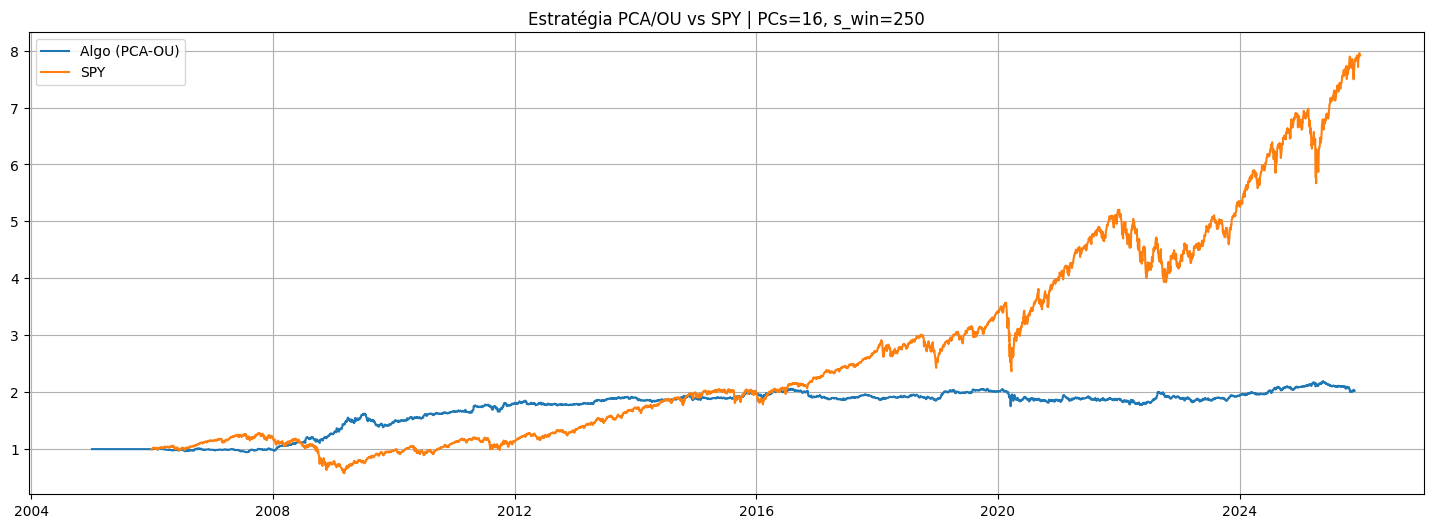

In [14]:
res_oos = pca_portfolio_spy_hedge(
    returns=returns_opt,
    returns_bench=bench_opt,
    benchmark="SPY",
    num_pc=int(best["num_pc"]),
    s_win=int(best["s_win"]),
    ma_window=int(best["ma_window"]),
    sbo=float(best["sbo"]),
    sso=float(best["sso"]),
    sbc=float(best["sbc"]),
    ssc=float(best["ssc"]),
    eps_cost=0.0005,
    rebalanceamento_dias=int(best["rebalanceamento_dias"]),
    kappa_min=float(best["kappa_min"]),
    plot=True,
    use_drift=True,
    verbose=True
)

In [15]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_res = res_oos['ret_net']
stats_res = stats_from_returns(ret_res)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2025)")
print("="*70)
for k, v in stats_res.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")


PERFORMANCE DA ESTRATÉGIA (1999-2025)
  CAGR      :     0.0343 (   3.43%)
  Vol       :     0.0723 (   7.23%)
  Sharpe    :     0.4746 (  47.46%)
  MaxDD     :    -0.1492 ( -14.92%)



In [ ]:
#pip install quantstats

In [ ]:
import quantstats as qs

#qs.reports.html(cum_algo, output="relatorio.html", title="Relatório da Estratégia")
